**OpenSim: Example Simple Coordinate Actuator**

In [80]:
import opensim as osim
import math

# Define the model
model = osim.Model()
model.setName('torque_example')
model.setGravity(osim.Vec3(0, -9.81, 0))
ground = model.getGround()

# Define the body
m = 1.0 
J = osim.Inertia(0.1, 0.1, 0.1)
pos_com = osim.Vec3(0, 0, 0)

head = osim.Body()
head.setName('head')
head.setMass(m)
head.setInertia(J)
head.setMassCenter(pos_com)
model.addBody(head)

# Pin joint for rotation of the head
joint_name = 'head_joint'
parent_physical_frame = ground
location_in_parent = osim.Vec3(0, 0, 0)
orientation_in_parent = osim.Vec3(math.pi/2, 0, 0)
child_physical_frame = head
location_in_child = osim.Vec3(0, 0, 0)
orientation_in_child = osim.Vec3(1, 0, 0)

joint = osim.PinJoint(
    joint_name,
    parent_physical_frame,
    location_in_parent,
    orientation_in_parent,
    child_physical_frame,
    location_in_child,
    orientation_in_child
)

model.addJoint(joint)

# Define coordinate
coord = joint.updCoordinate()
coord.setName('q')
coord.setDefaultValue(0)
coord.setDefaultSpeedValue(0)

# Define CoordinateActuator
act = osim.CoordinateActuator()
act.setName('torque')
act.setCoordinate(coord)
act.setOptimalForce(1)
act.setMinControl(-1e6)
act.setMaxControl(1e6)
model.addForce(act)

# Define controller
func = osim.Constant()
ctrl = osim.PrescribedController()
ctrl.setName('controller')
ctrl.addActuator(act)
ctrl.prescribeControlForActuator('torque', func)
model.addController(ctrl)

# Finalize and initialize the model
model.finalizeConnections()
state = model.initSystem()
act.overrideActuation(state, True)

model.realizePosition(state)
model.realizeVelocity(state)
model.realizeAcceleration(state)
model.realizeDynamics(state)

# Initialize Simulation Manager
manager = osim.Manager(model)
manager.setIntegratorAccuracy(1e-6)
manager.initialize(state)

#model.printToXML('torque_example.osim')

# Define simulation parameters
t = 0.0
dt = 0.01
tf = 10.0

print(f'Initial position:       {coord.getValue(state)} rad')
print(f'Initial speed:          {coord.getSpeedValue(state)} rad/s')
print(f'Initial acceleration:   {coord.getAccelerationValue(state)} rad/s²')
print(f'Initial torque:         {act.getActuation(state)} Nm')

Initial position:       0.0 rad
Initial speed:          0.0 rad/s
Initial acceleration:   0.0 rad/s²
Initial torque:         0.0 Nm


In [81]:
t_vals = []
q_vals = []
omega_vals = []
alpha_vals = []
torque_vals = []

In [82]:
while t < tf:
    if t < 0.25 * tf:
        act.setOverrideActuation(state, -0.05)
    elif t < 0.75 * tf:
        act.setOverrideActuation(state, 0.05)
    else:
        act.setOverrideActuation(state, -0.05)

    model.realizeDynamics(state)
    model.realizeAcceleration(state)

    state = manager.integrate(t + dt)
    model.realizePosition(state)
    model.realizeVelocity(state)
    model.realizeAcceleration(state)
    model.realizeDynamics(state)

    t = state.getTime()

    t_vals.append(t)
    q_vals.append(coord.getValue(state))
    omega_vals.append(coord.getSpeedValue(state))
    alpha_vals.append(coord.getAccelerationValue(state))
    torque_vals.append(act.getActuation(state))

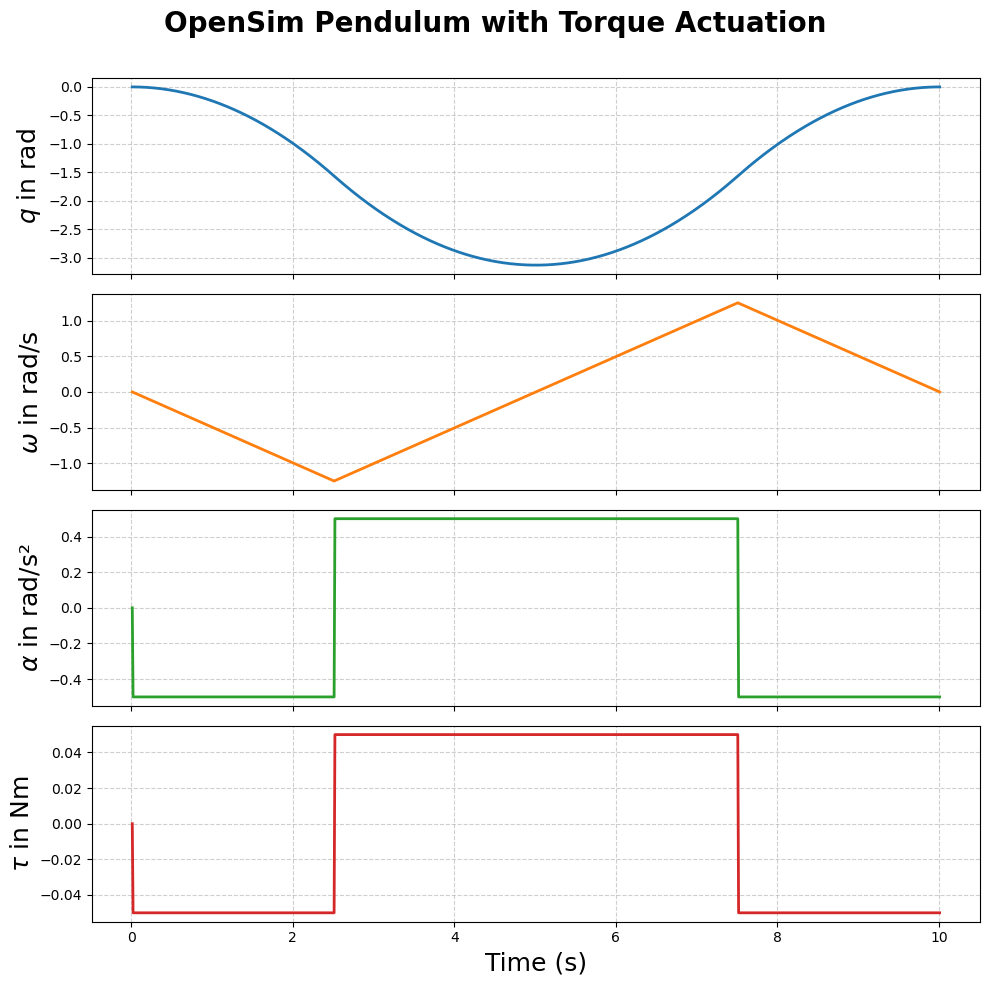

In [84]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
plt.suptitle('OpenSim Pendulum with Torque Actuation', fontsize=20, fontweight='bold')

# Position
axs[0].plot(t_vals, q_vals, label='Position', color='#1f77b4', linewidth=2)
axs[0].set_ylabel('$q$ in rad', fontsize=18)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Speed
axs[1].plot(t_vals, omega_vals, label='Speed', color='#ff7f0e', linewidth=2)
axs[1].set_ylabel('$\omega$ in rad/s', fontsize=18)
axs[1].grid(True, linestyle='--', alpha=0.6)

# Acceleration
axs[2].plot(t_vals, alpha_vals, label='Acceleration', color='#2ca02c', linewidth=2)
axs[2].set_ylabel('$\\alpha$ in rad/s²', fontsize=18)
axs[2].grid(True, linestyle='--', alpha=0.6)

# Torque
axs[3].plot(t_vals, torque_vals, label='Torque', color='#d62728', linewidth=2)
axs[3].set_ylabel('$\\tau$ in Nm', fontsize=18)
axs[3].set_xlabel('Time (s)', fontsize=18)
axs[3].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [78]:
import opensim as osim
from opensim import TimeSeriesTable, STOFileAdapter
import numpy as np

In [ ]:
data = {'q': np.array(q_vals),
        '/jointset/head_joint/q/speed': np.array(omega_vals)}

time = np.array(t_vals)
n_time_steps = len(time)
filename = 'torque_example_states.mot'

n_time_steps = time.shape[0]
table = TimeSeriesTable()

table.setColumnLabels(list(data.keys()))
    
# Append data rows to the table
for i in range(n_time_steps):
    n_data = len(data.keys())
    row = osim.RowVector(n_data)
    for j, key in enumerate(data.keys()):
        row[j] = data[key][i]
    table.appendRow(time[i], row)
    
# Write to .mot file
adapter = STOFileAdapter()
adapter.write(table, filename)

In [85]:
model.get_length_units()

'meters'

In [88]:
model.get_force_units()

'N'